# Libraries

In [608]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [609]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240610 - Ag60 GDE_0.3M K2SO4_pH3

16-Aug-26  11:53 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:03 PM    <DIR>          .ipynb_checkpoints
30-Jul-26  10:52 AM            72,666 0p3M_pH3 K2SO4_20240611_0641_1min - Copy.xlsx
30-Jul-26  10:54 AM            47,319 0p3M_pH3 K2SO4_20240611_0641_1min.xlsx
11-Jun-24  08:42 AM            10,661 0p3M_pH3 K2SO4_20240611_0641_5min.xlsx
11-Jun-24  08:42 AM           227,116 0p3M_pH3 K2SO4_20240611_0641_Line_1.csv
12-May-25  01:56 PM           706,862 20240610 - Ag60 GDE_0.3 M K2SO4_pH3.ipynb
16-Aug-26  11:53 PM           856,083 20240610 - Ag60 GDE_0.3 M K2SO4_pH3-CORRECTED.ipynb
16-Aug-26  11:29 PM               535 20240610_0.3 M K2SO4_pH3_Energy Consumption.csv
16-Aug-26  10:06 PM             5,889 20240610_0.3M K2SO4_pH3.csv
16-Aug-26  11:29 PM             1,416 202

# Load Data

In [610]:
Book = "Book_20240610 - Ag60 GDE_0.3 M K2SO4_pH3.xlsx"
Book = pd.read_excel(Book)
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,Unnamed: 25,Sum Concentrations
0,Ag60 GDE in PTFE holder,60,43.723558,0.3 M K2SO4,Deionized wated,CCM-CEM,0.0,2024-06-10 15:33:12.628,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000
1,Ag60 GDE in PTFE holder,60,50.478924,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.1,2024-06-10 15:55:33.000,0.372326,0.083528,...,0.980033,0.003376,0.054608,1.052623,NaN,1.107231,0.015822,NaN,NaN,102.192823
2,Ag60 GDE in PTFE holder,60,54.689800,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.1,2024-06-10 16:27:36.000,0.906492,0.090096,...,0.981767,0.001609,0.063449,1.138892,NaN,1.202342,0.015774,102.525492,NaN,102.782350


In [611]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,Unnamed: 25,Sum Concentrations,GC_flow_rate_ml_min
61,Ag60 GDE in PTFE holder,60,57.08,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-11 08:20:23,16.79,0.198338,...,0.000438,0.028983,0.034359,NaN,0.063343,0.002279,NaN,NaN,103.392525,57.08
62,Ag60 GDE in PTFE holder,60,57.47,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-11 08:35:25,17.04,0.091844,...,0.000408,0.013514,0.011998,NaN,0.025512,0.000790,103.25406,NaN,103.389287,57.47
63,Ag60 GDE in PTFE holder,60,12.03,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-11 08:50:25,17.29,0.068821,...,0.000387,0.002121,0.001944,NaN,0.004065,0.000611,NaN,NaN,103.281370,12.03


### Temp from pH meter

In [612]:
Temp = "2024-06-11_083941.csv"
Temp = pd.read_csv(Temp, sep = ",")
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 26.892544268406336
Temp C median: 25.2


### Power Supply

In [613]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.19V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,10.06.2024 15:33:12.628
1,40.00V,2.63V,0.100A,0.099A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,10.06.2024 15:33:17.641


In [614]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.19V
0.100A 1    2.63V
       2    2.82V

In [615]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "median",
        "U actual": "median"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-06-10 14:00:00     0.101      2.99
1 2024-06-10 16:00:00     0.100      3.05
2 2024-06-10 18:00:00     0.255      3.64
3 2024-06-10 20:00:00     0.502      4.46
4 2024-06-10 22:00:00     0.747      5.26
5 2024-06-11 00:00:00     0.998      6.00
6 2024-06-11 02:00:00     1.495      7.53
7 2024-06-11 04:00:00     1.991      8.97
8 2024-06-11 06:00:00     2.989     11.15


In [616]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[1:].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-06-10 16:00:00     0.100      3.05
1 2024-06-10 18:00:00     0.255      3.64
2 2024-06-10 20:00:00     0.502      4.46
3 2024-06-10 22:00:00     0.747      5.26
4 2024-06-11 00:00:00     0.998      6.00
5 2024-06-11 02:00:00     1.495      7.53
6 2024-06-11 04:00:00     1.991      8.97
7 2024-06-11 06:00:00     2.989     11.15


In [617]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [618]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.100,3.05
0.255,3.64
0.502,4.46
0.747,5.26
0.998,6.00
1.495,7.53
1.991,8.97
2.989,11.15


In [619]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.100,3.05,1.00
0.255,3.64,2.55
0.502,4.46,5.02
0.747,5.26,7.47
0.998,6.00,9.98
1.495,7.53,14.95
1.991,8.97,19.91
2.989,11.15,29.89


## Flow rate

In [620]:
flow_rate = "0p3M_pH3 K2SO4_20240611_0641_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-11 06:41:47.069000,NaN
1,Software version,Aurora 1.0.2,NaN
2,Instrument name,0p3M_pH3 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6e:f2:c4,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [621]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-06-10 13:32:59.971000,43.723558,21.861779
1,2024-06-10 13:34:00.019000,44.468509,22.234254
2,2024-06-10 13:34:59.981000,44.458089,22.229044
3,2024-06-10 13:36:00.029000,45.010498,22.505249
4,2024-06-10 13:36:59.990000,45.910494,22.955247
...,...,...,...
1025,2024-06-11 06:38:00.010000,58.192664,29.096332
1026,2024-06-11 06:38:59.971000,58.38853,29.194265
1027,2024-06-11 06:40:00.019000,58.493656,29.246828
1028,2024-06-11 06:40:59.981000,57.97864,28.98932


In [622]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-10 12:00:00     43.723558     51.189401      48.105694   
1 2024-06-10 14:00:00     50.981857     59.561789      56.564238   
2 2024-06-10 16:00:00     59.105478     61.039686      59.970058   
3 2024-06-10 18:00:00     59.501588     61.338218      60.331585   
4 2024-06-10 20:00:00     59.501763      60.93984      60.237293   
5 2024-06-10 22:00:00     59.392531     63.380784      60.674626   
6 2024-06-11 00:00:00     61.719161     66.494127      63.135688   
7 2024-06-11 02:00:00     64.751619     74.524469       67.34455   
8 2024-06-11 04:00:00     55.310559     73.840181      70.081824   
9 2024-06-11 06:00:00     12.025772     58.493656      55.664411   

  Flow_rate_median  
0        48.463685  
1        57.260224  
2        59.971874  
3        60.329607  
4         60.27387  
5        60.145312  
6        62.349326  
7        65.535892  
8        72.792758  
9        56.756033  


#### COrrection fro dry flow

In [623]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.480 L/mol
p_sat = 3.2065 kPa -> x(H2O) = 3.16 % -> dry factor 0.96835


In [624]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [625]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-2].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-06-10 12:00:00,43.723558,51.189401,48.105694,48.463685,42.339893,49.569474,46.583354,46.930015,0.100,3.05
1,2024-06-10 14:00:00,50.981857,59.561789,56.564238,57.260224,49.368498,57.676912,54.77422,55.448181,0.255,3.64
2,2024-06-10 16:00:00,59.105478,61.039686,59.970058,59.971874,57.235041,59.108039,58.072261,58.074019,0.502,4.46
3,2024-06-10 18:00:00,59.501588,61.338218,60.331585,60.329607,57.618616,59.397124,58.422347,58.420431,0.747,5.26
4,2024-06-10 20:00:00,59.501763,60.93984,60.237293,60.27387,57.618785,59.011353,58.331039,58.366458,0.998,6.00
5,2024-06-10 22:00:00,59.392531,63.380784,60.674626,60.145312,57.51301,61.375052,58.754532,58.241969,1.495,7.53
6,2024-06-11 00:00:00,61.719161,66.494127,63.135688,62.349326,59.766012,64.38987,61.137712,60.376235,1.991,8.97
7,2024-06-11 02:00:00,64.751619,74.524469,67.34455,65.535892,62.702505,72.166086,65.213381,63.46196,2.989,11.15


In [628]:
# dfflow_rate.to_csv('20240610_0.3M K2SO4_pH3_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [629]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.100,3.05,1.00,100.0
0.255,3.64,2.55,255.0
0.502,4.46,5.02,502.0


In [630]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.100,3.05,1.00,100.0,2196.000
0.255,3.64,2.55,255.0,6683.040
0.502,4.46,5.02,502.0,16120.224
0.747,5.26,7.47,747.0,28290.384
0.998,6.00,9.98,998.0,43113.600
1.495,7.53,14.95,1495.0,81052.920
1.991,8.97,19.91,1991.0,128586.744
2.989,11.15,29.89,2989.0,239956.920


In [631]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.100,3.05,1.00,100.0,2196.000,0.000610
0.255,3.64,2.55,255.0,6683.040,0.001856
0.502,4.46,5.02,502.0,16120.224,0.004478
0.747,5.26,7.47,747.0,28290.384,0.007858
0.998,6.00,9.98,998.0,43113.600,0.011976
1.495,7.53,14.95,1495.0,81052.920,0.022515
1.991,8.97,19.91,1991.0,128586.744,0.035719
2.989,11.15,29.89,2989.0,239956.920,0.066655


In [634]:
# dfcell_voltage.to_csv('20240610_0.3 M K2SO4_pH3_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [635]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,Unnamed: 25,Sum Concentrations,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,43.72,0.3 M K2SO4,Deionized wated,CCM-CEM,0.00,2024-06-10 15:33:12.628,0.00,0.000000,...,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,43.72,0.0
1,Ag60 GDE in PTFE holder,60,50.48,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.10,2024-06-10 15:55:33.000,0.37,0.083528,...,0.054608,1.052623,NaN,1.107231,0.015822,NaN,NaN,102.192823,50.48,0.0
2,Ag60 GDE in PTFE holder,60,54.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.10,2024-06-10 16:27:36.000,0.91,0.090096,...,0.063449,1.138892,NaN,1.202342,0.015774,102.525492,NaN,102.782350,54.69,0.0
3,Ag60 GDE in PTFE holder,60,57.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.10,2024-06-10 16:59:37.000,1.44,0.022804,...,0.016732,1.186709,NaN,1.203441,0.015749,NaN,NaN,103.170459,57.19,1.0
4,Ag60 GDE in PTFE holder,60,57.77,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.10,2024-06-10 17:14:37.000,1.69,0.036254,...,0.027013,1.202366,NaN,1.229379,0.015745,102.490255,NaN,102.615602,57.77,1.0
5,Ag60 GDE in PTFE holder,60,59.44,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 17:59:39.000,2.44,0.210800,...,0.059314,0.959122,NaN,1.018435,0.033011,NaN,NaN,103.551088,59.44,2.0
6,Ag60 GDE in PTFE holder,60,59.88,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 18:34:40.000,3.02,0.222147,...,0.063459,0.960004,NaN,1.023462,0.032801,102.455399,NaN,102.748442,59.88,3.0
7,Ag60 GDE in PTFE holder,60,59.57,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 18:49:39.000,3.27,0.233398,...,0.066531,0.955859,NaN,1.022390,0.032824,NaN,NaN,102.442743,59.57,3.0
8,Ag60 GDE in PTFE holder,60,59.75,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 19:04:39.000,3.52,0.238105,...,0.068007,0.954300,NaN,1.022308,0.032675,102.253830,NaN,102.539168,59.75,3.0
9,Ag60 GDE in PTFE holder,60,59.90,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 19:19:41.000,3.77,0.242356,...,0.069417,0.955026,NaN,1.024442,0.032618,NaN,NaN,102.510267,59.90,3.0


## Current Density

In [636]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,Unnamed: 25,Sum Concentrations,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,43.72,0.3 M K2SO4,Deionized wated,CCM-CEM,0.00,2024-06-10 15:33:12.628,0.00,0.000000,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,43.72,0.0,0.0
1,Ag60 GDE in PTFE holder,60,50.48,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.10,2024-06-10 15:55:33.000,0.37,0.083528,...,1.052623,NaN,1.107231,0.015822,NaN,NaN,102.192823,50.48,0.0,-100.0
2,Ag60 GDE in PTFE holder,60,54.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.10,2024-06-10 16:27:36.000,0.91,0.090096,...,1.138892,NaN,1.202342,0.015774,102.525492,NaN,102.782350,54.69,0.0,-100.0
3,Ag60 GDE in PTFE holder,60,57.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.10,2024-06-10 16:59:37.000,1.44,0.022804,...,1.186709,NaN,1.203441,0.015749,NaN,NaN,103.170459,57.19,1.0,-100.0
4,Ag60 GDE in PTFE holder,60,57.77,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.10,2024-06-10 17:14:37.000,1.69,0.036254,...,1.202366,NaN,1.229379,0.015745,102.490255,NaN,102.615602,57.77,1.0,-100.0
5,Ag60 GDE in PTFE holder,60,59.44,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 17:59:39.000,2.44,0.210800,...,0.959122,NaN,1.018435,0.033011,NaN,NaN,103.551088,59.44,2.0,-270.0
6,Ag60 GDE in PTFE holder,60,59.88,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 18:34:40.000,3.02,0.222147,...,0.960004,NaN,1.023462,0.032801,102.455399,NaN,102.748442,59.88,3.0,-270.0
7,Ag60 GDE in PTFE holder,60,59.57,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 18:49:39.000,3.27,0.233398,...,0.955859,NaN,1.022390,0.032824,NaN,NaN,102.442743,59.57,3.0,-270.0
8,Ag60 GDE in PTFE holder,60,59.75,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 19:04:39.000,3.52,0.238105,...,0.954300,NaN,1.022308,0.032675,102.253830,NaN,102.539168,59.75,3.0,-270.0
9,Ag60 GDE in PTFE holder,60,59.90,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-10 19:19:41.000,3.77,0.242356,...,0.955026,NaN,1.024442,0.032618,NaN,NaN,102.510267,59.90,3.0,-270.0


## FE(CO)

In [637]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [638]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.480 L/mol


In [639]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.1, 0.255, 0.502, 0.747, 0.998, 1.495, 1.991, 2.989]

In [640]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[5, 5, 8, 8, 8, 8, 8, 8]

In [641]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.100                0.000  0.016
0.255                0.002  0.033
0.502                0.004  0.059
0.747                0.006  0.083
0.998                0.014  0.105
1.495                0.045  0.122
1.991                0.087  0.126
2.989                0.167  0.124


In [642]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 102.4 / 85.7 %


In [643]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,50.48,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 15:55:33,0.37,0.083528,...,50.48,0.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,102.179920
2,Ag60 GDE in PTFE holder,60,54.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 16:27:36,0.91,0.090096,...,54.69,0.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,102.413936
7,Ag60 GDE in PTFE holder,60,59.57,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 18:49:39,3.27,0.233398,...,59.57,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,100.016382


In [644]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.02].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.03].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.03].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.03].index)
rows = rows.drop(rows[rows['Duration / h'] == 12.03].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.03].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,50.48,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 15:55:33,0.37,0.083528,...,50.48,0.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,102.179920
2,Ag60 GDE in PTFE holder,60,54.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 16:27:36,0.91,0.090096,...,54.69,0.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,102.413936
3,Ag60 GDE in PTFE holder,60,57.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 16:59:37,1.44,0.022804,...,57.19,1.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,98.017753
4,Ag60 GDE in PTFE holder,60,57.77,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 17:14:37,1.69,0.036254,...,57.77,1.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,99.135587
5,Ag60 GDE in PTFE holder,60,59.44,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 17:59:39,2.44,0.210800,...,59.44,2.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,99.852865
6,Ag60 GDE in PTFE holder,60,59.88,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 18:34:40,3.02,0.222147,...,59.88,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,99.612175
7,Ag60 GDE in PTFE holder,60,59.57,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 18:49:39,3.27,0.233398,...,59.57,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,100.016382
8,Ag60 GDE in PTFE holder,60,59.75,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 19:04:39,3.52,0.238105,...,59.75,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,99.717812
9,Ag60 GDE in PTFE holder,60,59.90,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 19:19:41,3.77,0.242356,...,59.90,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,99.672922
10,Ag60 GDE in PTFE holder,60,59.91,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.502,2024-06-10 21:19:44,5.78,0.354562,...,59.91,5.0,-502.0,0.52,0.502,58.072261,57.235041,59.108039,58.074019,95.970135


### Mean FE per current density

In [645]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        100    3.496259   96.940540      3.608856     96.983355   1.012894   
1        255    6.377536   93.396896      6.508511     93.435844   0.170408   
2        502    5.405282   89.466576      5.412473     90.030388   0.040958   
3        747    5.754090   84.751083      5.747366     85.239923   0.059117   
4        998   10.457530   80.305007     10.587641     80.753870   0.160609   
5       1495   23.286894   62.272591     23.310406     62.404829   0.289175   
6       1991   34.428212   50.436951     34.802257     50.304679   0.282340   
7       2989   46.593674   34.286126     46.988113     34.431974   0.541359   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   0.102702   2.025788   0.205405   1.974422  ...   0.000567     0.000585  4   
1   0.193676   0.381044   0.433072   6.176331  ...   0.002232     0.002278  5   
2   0.667078   0.108365   1.764921   5.346467

## FE(H2)

In [646]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(CO)"])
# Book

1     97.140501
2     97.009418
3     96.654946
4     96.957293
5     94.037442
6     93.435844
7     93.507872
8     93.084273
9     92.919047
10    90.742472
11    90.521642
12    89.614742
13    90.256029
14    89.505106
15    85.595652
17    90.030388
19    82.178273
20    84.573725
21    84.948364
22    85.239923
23    85.371919
24    85.414763
25    85.530616
26    80.753870
27    80.780172
28    81.020287
29    80.899893
30    79.864055
31    78.314274
33    80.502497
34    62.404829
36    61.038811
37    61.603061
38    63.435631
39    62.675621
40    62.290015
41    62.460168
42    50.248252
43    50.304679
44    51.527673
45    50.288288
46    50.306495
47    49.911175
49    50.472096
50    34.431974
51    34.159591
52    34.723014
53    33.835028
54    34.557359
56    34.622475
57    33.673441
Name: FE(CO), dtype: float64


# Plots

## Current Density vs Time

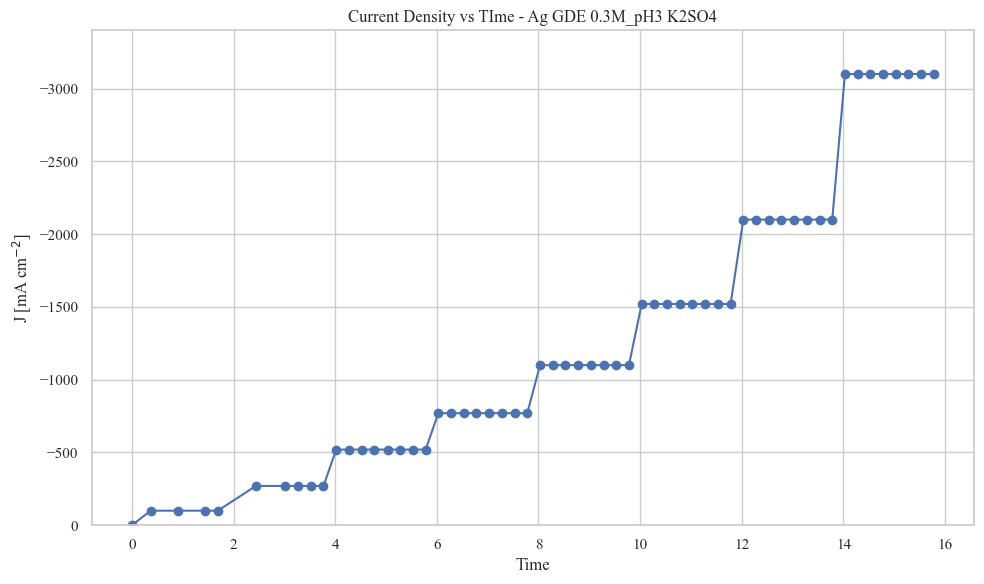

In [647]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH3 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

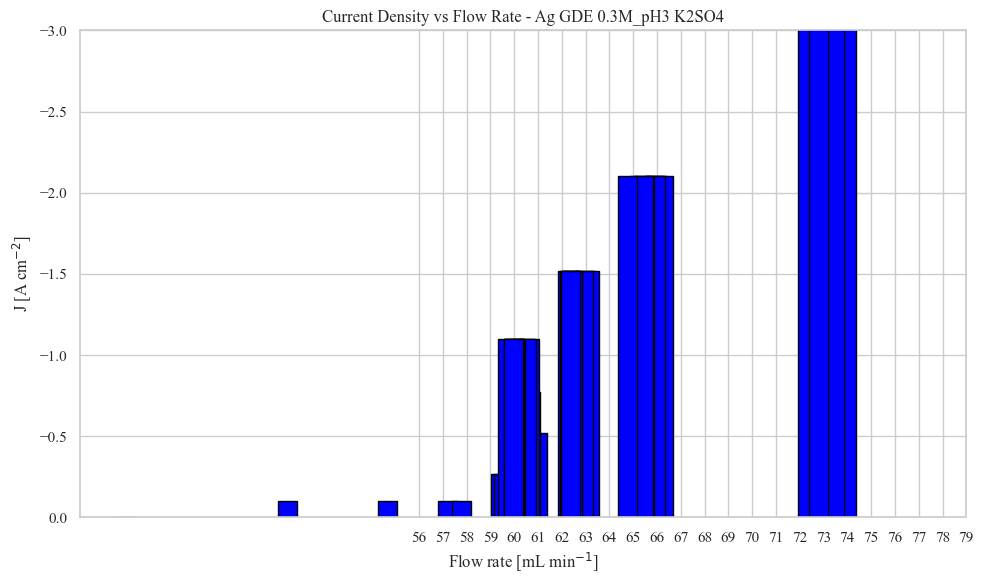

In [648]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH3 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


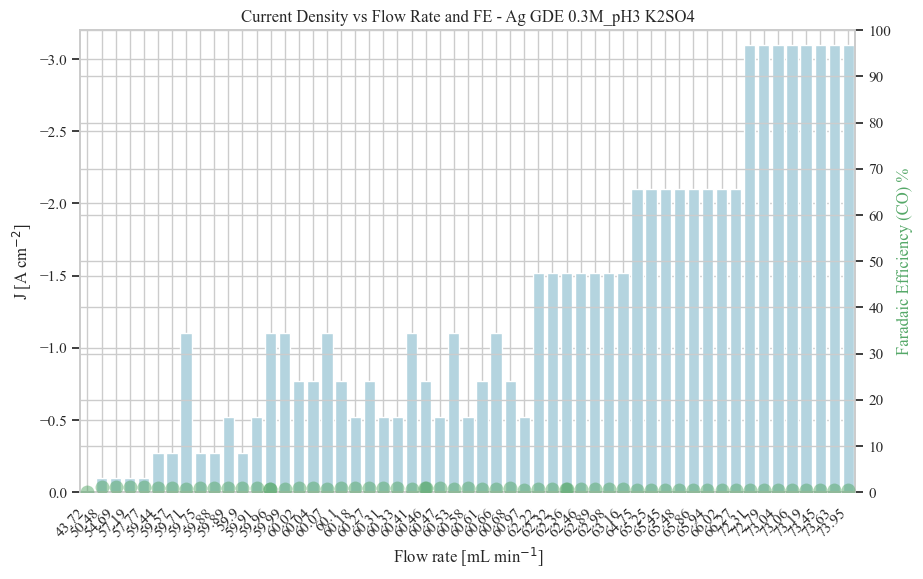

In [649]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH3 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240610_Ag_GDE_0_3M_pH3_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [650]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [651]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240610 - Ag60 GDE_0.3M K2SO4_pH3

16-Aug-26  11:53 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:03 PM    <DIR>          .ipynb_checkpoints
30-Jul-26  10:52 AM            72,666 0p3M_pH3 K2SO4_20240611_0641_1min - Copy.xlsx
30-Jul-26  10:54 AM            47,319 0p3M_pH3 K2SO4_20240611_0641_1min.xlsx
11-Jun-24  08:42 AM            10,661 0p3M_pH3 K2SO4_20240611_0641_5min.xlsx
11-Jun-24  08:42 AM           227,116 0p3M_pH3 K2SO4_20240611_0641_Line_1.csv
12-May-25  01:56 PM           706,862 20240610 - Ag60 GDE_0.3 M K2SO4_pH3.ipynb
16-Aug-26  11:53 PM           856,083 20240610 - Ag60 GDE_0.3 M K2SO4_pH3-CORRECTED.ipynb
17-Aug-26  12:06 AM               535 20240610_0.3 M K2SO4_pH3_Energy Consumption.csv
16-Aug-26  10:06 PM             5,889 20240610_0.3M K2SO4_pH3.csv
17-Aug-26  12:06 AM             1,416 202

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


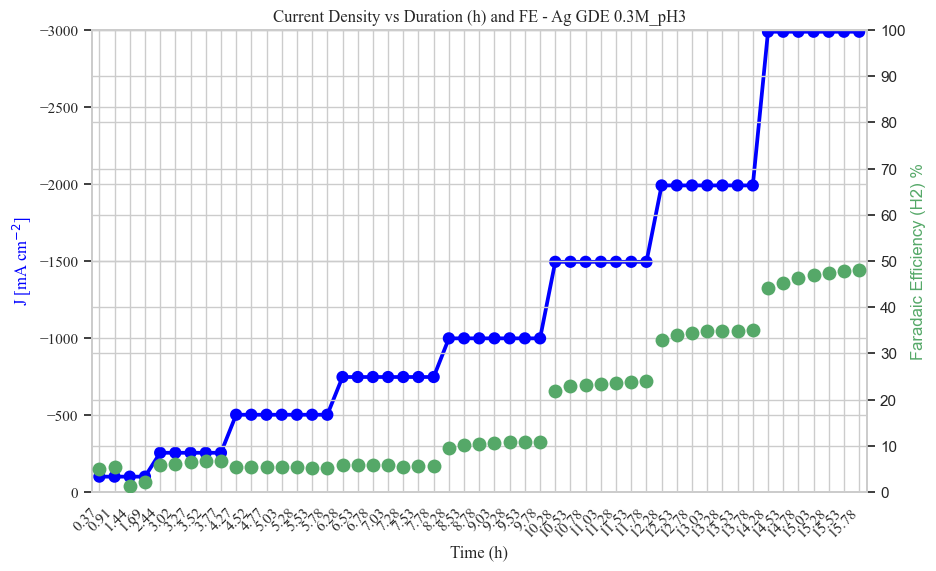

In [652]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.3M_pH3')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -340)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(H2)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (H2) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240610_Ag_GDE_0_3M_pH3_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points from initial step in each current

In [653]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.02].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.03].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.03].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.03].index)
rows = rows.drop(rows[rows['Duration / h'] == 12.03].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.03].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,50.48,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 15:55:33,0.37,0.083528,...,50.48,0.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,102.179920
2,Ag60 GDE in PTFE holder,60,54.69,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 16:27:36,0.91,0.090096,...,54.69,0.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,102.413936
3,Ag60 GDE in PTFE holder,60,57.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 16:59:37,1.44,0.022804,...,57.19,1.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,98.017753
4,Ag60 GDE in PTFE holder,60,57.77,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.100,2024-06-10 17:14:37,1.69,0.036254,...,57.77,1.0,-100.0,0.10,0.100,46.583354,42.339893,49.569474,46.930015,99.135587
5,Ag60 GDE in PTFE holder,60,59.44,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 17:59:39,2.44,0.210800,...,59.44,2.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,99.852865
6,Ag60 GDE in PTFE holder,60,59.88,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 18:34:40,3.02,0.222147,...,59.88,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,99.612175
7,Ag60 GDE in PTFE holder,60,59.57,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 18:49:39,3.27,0.233398,...,59.57,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,100.016382
8,Ag60 GDE in PTFE holder,60,59.75,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 19:04:39,3.52,0.238105,...,59.75,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,99.717812
9,Ag60 GDE in PTFE holder,60,59.90,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.255,2024-06-10 19:19:41,3.77,0.242356,...,59.90,3.0,-255.0,0.27,0.255,54.77422,49.368498,57.676912,55.448181,99.672922
10,Ag60 GDE in PTFE holder,60,59.91,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.502,2024-06-10 21:19:44,5.78,0.354562,...,59.91,5.0,-502.0,0.52,0.502,58.072261,57.235041,59.108039,58.074019,95.970135


## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

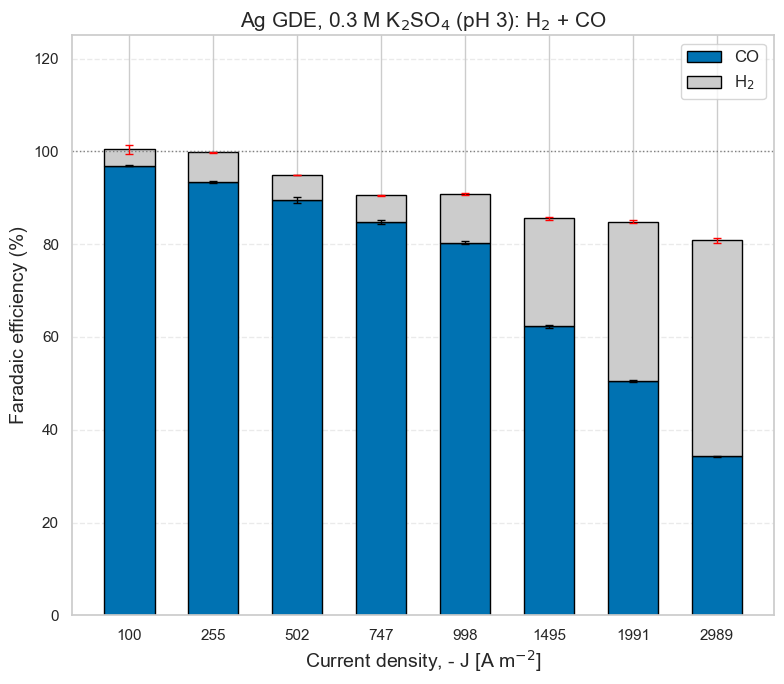

In [654]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M K$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

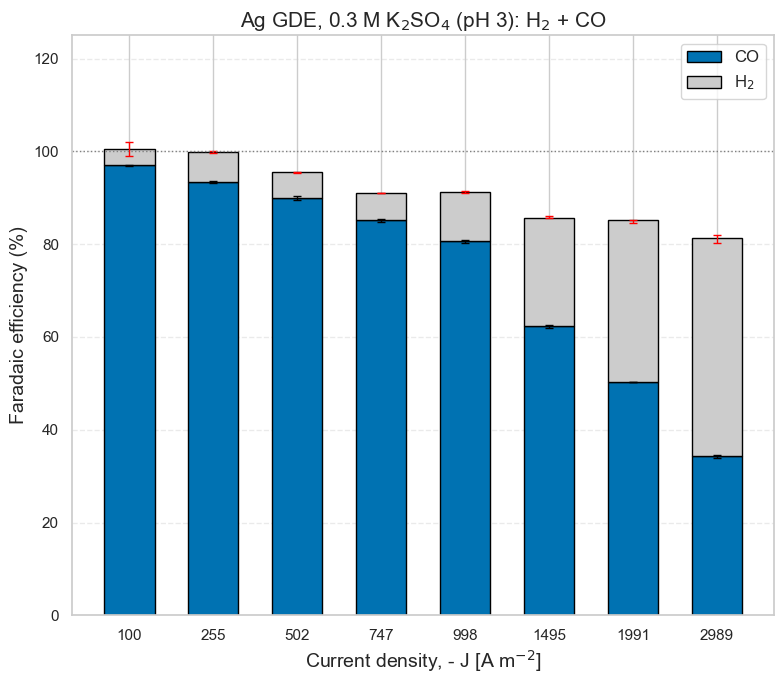

In [655]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M K$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [656]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [657]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,3.496259,96.940540,3.608856,96.983355,1.012894,0.102702,2.025788,0.205405,1.974422,...,0.000585,4,1.634434,1.521837,0.101649,0.058833,1.801625,1.580671,0–2,100
1,250,6.377536,93.396896,6.508511,93.435844,0.170408,0.193676,0.381044,0.433072,6.176331,...,0.002278,5,0.332180,0.125028,0.351571,0.072027,0.044890,0.135053,2–4,255
2,500,5.405282,89.466576,5.412473,90.030388,0.040958,0.667078,0.108365,1.764921,5.346467,...,0.003561,7,0.066006,0.075540,0.470464,0.358447,0.492980,0.239066,4–6,502
3,750,5.754090,84.751083,5.747366,85.239923,0.059117,0.446208,0.156409,1.180556,5.675732,...,0.005594,7,0.071634,0.119143,0.478879,0.153418,0.204380,0.188022,6–8,747
4,1000,10.457530,80.305007,10.587641,80.753870,0.160609,0.361519,0.424930,0.956489,10.370530,...,0.013780,7,0.217111,0.161199,0.570593,0.086163,0.933728,0.040553,8–10,998
5,1500,23.286894,62.272591,23.310406,62.404829,0.289175,0.290261,0.765086,0.767958,23.154628,...,0.045544,7,0.155778,0.442332,0.458290,0.163066,0.673483,0.421910,10–12,1495
6,2000,34.428212,50.436951,34.802257,50.304679,0.282340,0.192698,0.747001,0.509832,34.168827,...,0.087356,7,0.633431,0.062558,0.036409,0.084616,0.532424,0.198859,12–14,1991
7,3000,46.593674,34.286126,46.988113,34.431974,0.541359,0.153818,1.432301,0.406965,45.826110,...,0.168454,7,1.162003,0.621747,0.434665,0.157942,0.921233,0.187082,14–16,2989


In [660]:
Res_Book
# Res_Book.to_csv('20240610_0.3M K2SO4_pH3.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,3.496259,96.940540,3.608856,96.983355,1.012894,0.102702,2.025788,0.205405,1.974422,...,0.000585,4,1.634434,1.521837,0.101649,0.058833,1.801625,1.580671,0–2,100
1,250,6.377536,93.396896,6.508511,93.435844,0.170408,0.193676,0.381044,0.433072,6.176331,...,0.002278,5,0.332180,0.125028,0.351571,0.072027,0.044890,0.135053,2–4,255
2,500,5.405282,89.466576,5.412473,90.030388,0.040958,0.667078,0.108365,1.764921,5.346467,...,0.003561,7,0.066006,0.075540,0.470464,0.358447,0.492980,0.239066,4–6,502
3,750,5.754090,84.751083,5.747366,85.239923,0.059117,0.446208,0.156409,1.180556,5.675732,...,0.005594,7,0.071634,0.119143,0.478879,0.153418,0.204380,0.188022,6–8,747
4,1000,10.457530,80.305007,10.587641,80.753870,0.160609,0.361519,0.424930,0.956489,10.370530,...,0.013780,7,0.217111,0.161199,0.570593,0.086163,0.933728,0.040553,8–10,998
5,1500,23.286894,62.272591,23.310406,62.404829,0.289175,0.290261,0.765086,0.767958,23.154628,...,0.045544,7,0.155778,0.442332,0.458290,0.163066,0.673483,0.421910,10–12,1495
6,2000,34.428212,50.436951,34.802257,50.304679,0.282340,0.192698,0.747001,0.509832,34.168827,...,0.087356,7,0.633431,0.062558,0.036409,0.084616,0.532424,0.198859,12–14,1991
7,3000,46.593674,34.286126,46.988113,34.431974,0.541359,0.153818,1.432301,0.406965,45.826110,...,0.168454,7,1.162003,0.621747,0.434665,0.157942,0.921233,0.187082,14–16,2989


## Mean and StD of FE(CO) through time

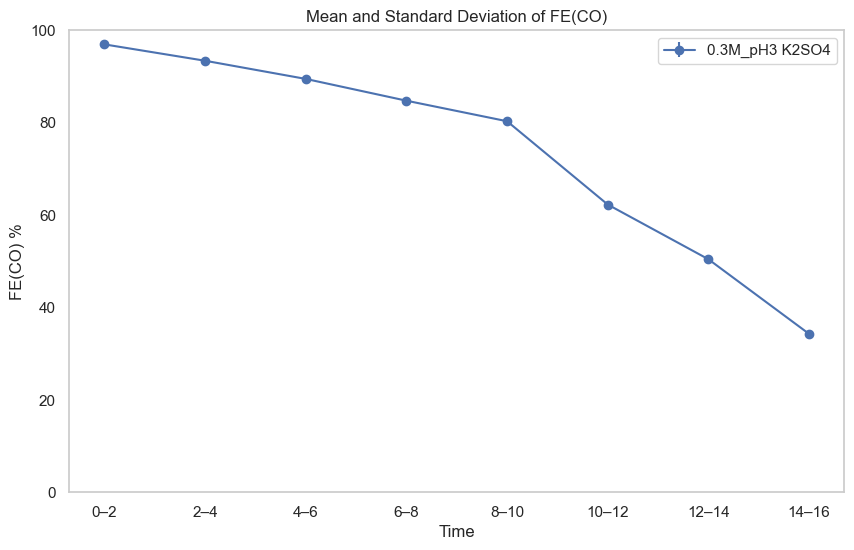

In [661]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.3M_pH3 K2SO4')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240610_0.3M_pH3_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

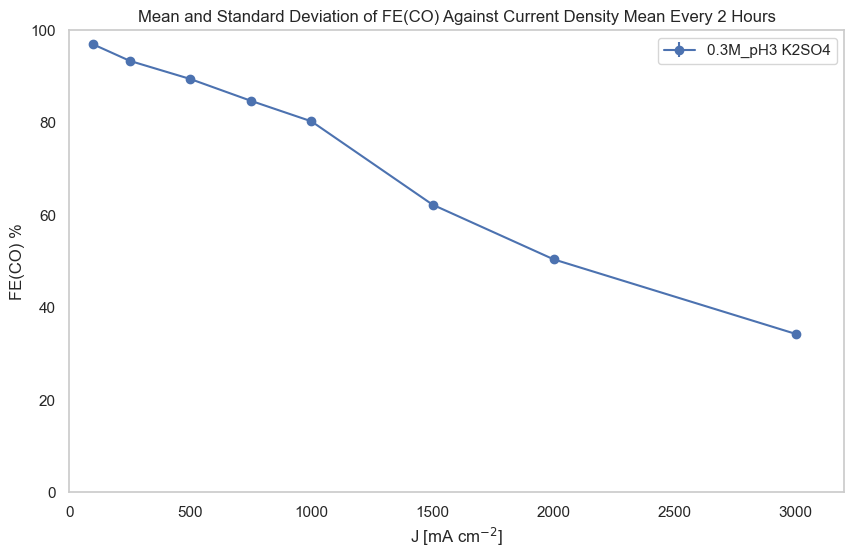

In [662]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.3M_pH3 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [mA cm$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240610_0.3M_pH3_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()